# Phase 8: Solar Precursor Dataset (Geomagnetic aa Index & Polar Field)

**Goal:** Build a precursor feature dataset using two well-established solar-cycle precursor signals,
measured around each cycle's minimum:

- **Geomagnetic aa index** (Ohl precursor method, 1900-2024 coverage) — geomagnetic activity during
  the declining phase / minimum of a cycle correlates with the *amplitude* of the upcoming cycle.
- **Polar field strength** (Schatten/SODA precursor method, Wilcox Solar Observatory, 1976-2025 coverage) —
  the Sun's polar magnetic field strength near minimum correlates with the amplitude of the next cycle.

These features will be merged into the cycle database for use in Phase 8b (precursor-augmented
amplitude/timing forecasting).


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
from io import StringIO

DATA_DIR = Path('../data')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

cyc = pd.read_csv(DATA_DIR / 'Cycle_Database_completed.csv', parse_dates=['Start_Date', 'Peak_Date', 'End_Date'])
print(f"Loaded {len(cyc)} cycles (SC{int(cyc['Cycle_ID'].min())}-SC{int(cyc['Cycle_ID'].max())})")
cyc[['Cycle_ID', 'Start_Date', 'Peak_Date', 'Peak_Sunspot_Number', 'Rise_Time_months']].head()


Loaded 24 cycles (SC1-SC24)


,Cycle_ID,Start_Date,Peak_Date,Peak_Sunspot_Number,Rise_Time_months
0,1,1755-02-01,1761-06-01,144.1,76.0
1,2,1766-06-01,1769-09-01,193.0,39.0
2,3,1775-06-01,1778-05-01,264.2,35.0
3,4,1784-09-01,1788-02-01,235.3,41.0
4,5,1798-04-01,1805-02-01,82.0,82.0


## 2. Load Geomagnetic aa Index (1900-2024)

In [2]:
def load_aa_file(path):
    """Parse an IAGA2002-format aa index file into a daily dataframe."""
    with open(path) as f:
        lines = f.readlines()
    header_idx = next(i for i, l in enumerate(lines) if l.strip().startswith('DATE'))
    data_str = ''.join(lines[header_idx + 1:])
    df = pd.read_csv(StringIO(data_str), sep=r'\s+',
                      names=['DATE', 'TIME', 'DOY', 'aa', 'Kpa', 'Aa', 'CK24', 'CK48'])
    df['date'] = pd.to_datetime(df['DATE'])
    df['aa'] = pd.to_numeric(df['aa'], errors='coerce')
    df.loc[df['aa'] >= 999, 'aa'] = np.nan
    return df[['date', 'aa']]

aa_1900 = load_aa_file(DATA_DIR / 'aa_1900-01-01_1999-12-31_D.dat')
aa_2000 = load_aa_file(DATA_DIR / 'aa_2000-01-01_2024-12-31_D.dat')
aa_daily = (pd.concat([aa_1900, aa_2000])
              .drop_duplicates(subset='date')
              .sort_values('date')
              .reset_index(drop=True))

print(f"aa index daily (3-hourly) records: {len(aa_daily)}")
print(f"Date range: {aa_daily['date'].min().date()} to {aa_daily['date'].max().date()}")
print(f"Missing values (999): {aa_daily['aa'].isna().sum()}")

# Monthly mean aa index
aa_monthly = aa_daily.set_index('date')['aa'].resample('MS').mean().reset_index()
aa_monthly.columns = ['date', 'aa_monthly']
aa_monthly.head()


aa index daily (3-hourly) records: 45656
Date range: 1900-01-01 to 2024-12-31
Missing values (999): 0


,date,aa_monthly
0,1900-01-01,11.419355
1,1900-02-01,8.178571
2,1900-03-01,11.612903
3,1900-04-01,8.066667
4,1900-05-01,6.774194


## 3. Load Solar Polar Field Data (1976-2025)

In [3]:
def load_polar_field(path):
    """Parse Wilcox Solar Observatory polar field text file.

    Line format example:
    1976:05:31_21h:07m:13s    89N -126S  108Avg   20nhz filt:  111Nf  -92Sf  101Avgf
    """
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            date_str = line.split('_')[0]  # e.g. '1976:05:31'
            try:
                date = pd.to_datetime(date_str, format='%Y:%m:%d')
            except ValueError:
                continue
            m = re.search(r'(-?\d+)Avg\b', line)  # the unfiltered "Avg" field (not "Avgf")
            if m is None:
                continue
            rows.append((date, float(m.group(1))))
    return pd.DataFrame(rows, columns=['date', 'polar_field_avg'])

pf_raw = load_polar_field(DATA_DIR / 'polar_field.txt')
print(f"Polar field raw records: {len(pf_raw)}")
print(f"Date range: {pf_raw['date'].min().date()} to {pf_raw['date'].max().date()}")

pf_raw['polar_field_abs'] = pf_raw['polar_field_avg'].abs()

# Monthly mean (signed average field, and unsigned/absolute strength)
pf_monthly = (pf_raw.set_index('date')[['polar_field_avg', 'polar_field_abs']]
                     .resample('MS').mean().reset_index())
pf_monthly.head()


Polar field raw records: 1793
Date range: 1976-05-31 to 2025-12-20


,date,polar_field_avg,polar_field_abs
0,1976-05-01,108.000000,108.000000
1,1976-06-01,111.000000,111.000000
2,1976-07-01,111.666667,111.666667
3,1976-08-01,100.333333,100.333333
4,1976-09-01,93.666667,93.666667


## 4. Visualize Precursor Time Series

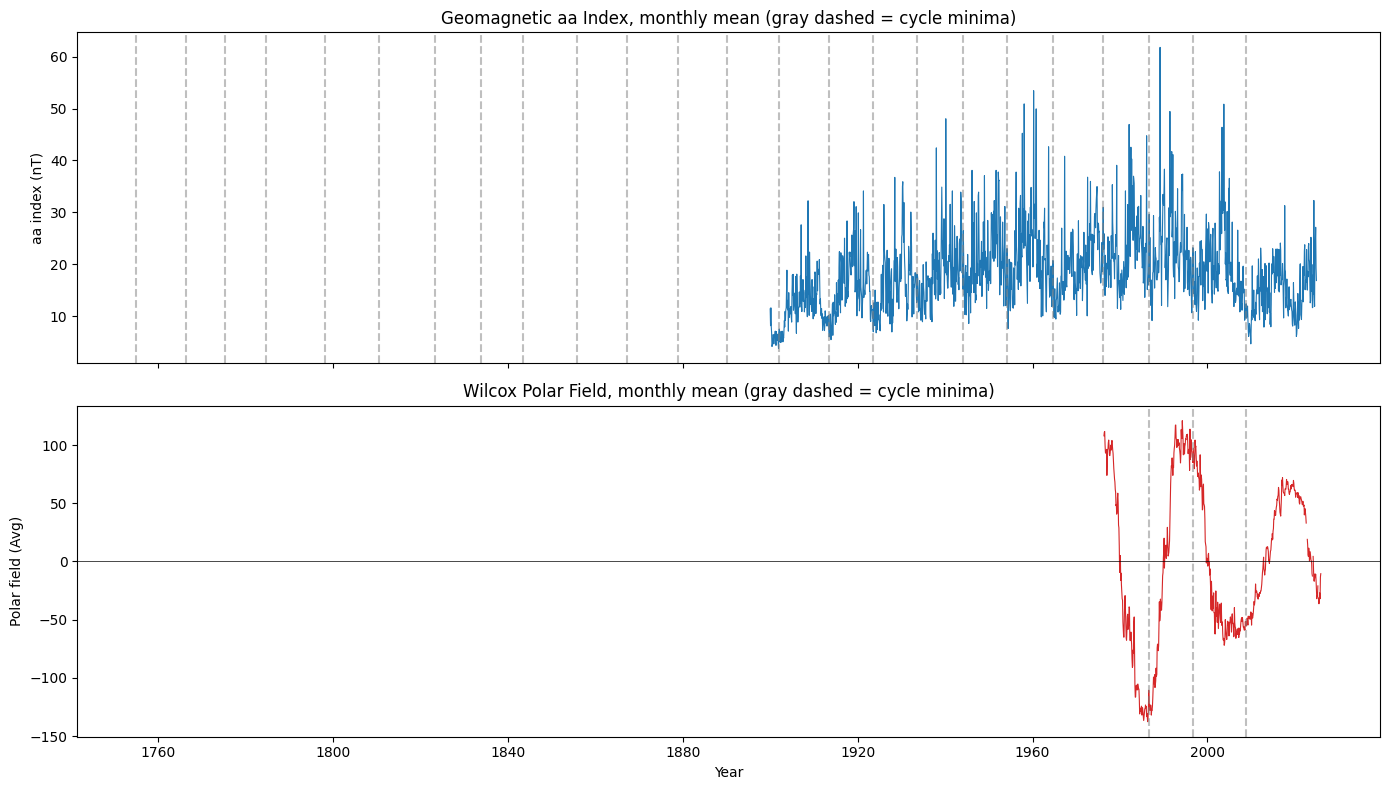

Saved plots/p8_precursor_timeseries.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(aa_monthly['date'], aa_monthly['aa_monthly'], color='tab:blue', lw=0.8)
for _, row in cyc.iterrows():
    axes[0].axvline(row['Start_Date'], color='gray', ls='--', alpha=0.5)
axes[0].set_ylabel('aa index (nT)')
axes[0].set_title('Geomagnetic aa Index, monthly mean (gray dashed = cycle minima)')

axes[1].plot(pf_monthly['date'], pf_monthly['polar_field_avg'], color='tab:red', lw=0.8)
axes[1].axhline(0, color='black', lw=0.5)
for _, row in cyc.iterrows():
    if row['Start_Date'] >= pf_monthly['date'].min():
        axes[1].axvline(row['Start_Date'], color='gray', ls='--', alpha=0.5)
axes[1].set_ylabel('Polar field (Avg)')
axes[1].set_title('Wilcox Polar Field, monthly mean (gray dashed = cycle minima)')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p8_precursor_timeseries.png', dpi=120)
plt.show()
print("Saved plots/p8_precursor_timeseries.png")


## 5. Extract Precursor Features at Each Cycle Minimum

For every cycle, `Start_Date` marks the solar minimum (= the start of that cycle). We extract:

- **`aa_at_min`** — mean aa index in a ±6 month window centered on the minimum
- **`aa_pre12`** / **`aa_pre24`** — mean aa index over the 12 / 24 months *before* the minimum
  (Ohl precursor: descending-phase geomagnetic activity)
- **`polar_field_at_min`** — mean signed polar field in a ±6 month window around the minimum
- **`polar_field_abs_at_min`** — mean |polar field| in the same window (Schatten/SODA precursor)


In [5]:
def window_mean(series_df, value_col, center_date, months_before, months_after):
    start = center_date - pd.DateOffset(months=months_before)
    end = center_date + pd.DateOffset(months=months_after)
    mask = (series_df['date'] >= start) & (series_df['date'] <= end)
    vals = series_df.loc[mask, value_col]
    return vals.mean() if len(vals) > 0 else np.nan

precursor_rows = []
for _, row in cyc.iterrows():
    cid = int(row['Cycle_ID'])
    start = row['Start_Date']
    feat = {'Cycle_ID': cid, 'Start_Date': start}
    # Geomagnetic aa index precursors
    feat['aa_at_min'] = window_mean(aa_monthly, 'aa_monthly', start, 6, 6)
    feat['aa_pre12']  = window_mean(aa_monthly, 'aa_monthly', start, 12, 0)
    feat['aa_pre24']  = window_mean(aa_monthly, 'aa_monthly', start, 24, 0)
    # Polar field precursors
    feat['polar_field_at_min']     = window_mean(pf_monthly, 'polar_field_avg', start, 6, 6)
    feat['polar_field_abs_at_min'] = window_mean(pf_monthly, 'polar_field_abs', start, 6, 6)
    precursor_rows.append(feat)

precursors = pd.DataFrame(precursor_rows)
precursors


,Cycle_ID,Start_Date,aa_at_min,aa_pre12,aa_pre24,polar_field_at_min,polar_field_abs_at_min
0,1,1755-02-01,NaN,NaN,NaN,NaN,NaN
1,2,1766-06-01,NaN,NaN,NaN,NaN,NaN
2,3,1775-06-01,NaN,NaN,NaN,NaN,NaN
3,4,1784-09-01,NaN,NaN,NaN,NaN,NaN
4,5,1798-04-01,NaN,NaN,NaN,NaN,NaN
5,6,1810-07-01,NaN,NaN,NaN,NaN,NaN
6,7,1823-05-01,NaN,NaN,NaN,NaN,NaN
7,8,1833-11-01,NaN,NaN,NaN,NaN,NaN
8,9,1843-07-01,NaN,NaN,NaN,NaN,NaN
9,10,1855-12-01,NaN,NaN,NaN,NaN,NaN


## 6. Data Coverage Summary

In [6]:
coverage = precursors.copy()
coverage['has_aa'] = coverage['aa_pre24'].notna()
coverage['has_polar'] = coverage['polar_field_at_min'].notna()
coverage['Cycle'] = 'SC' + coverage['Cycle_ID'].astype(str)

print("Precursor data coverage by cycle:\n")
print(coverage[['Cycle', 'Start_Date', 'has_aa', 'has_polar']].to_string(index=False))

print(f"\nCycles with full aa precursor (24m lookback): {coverage['has_aa'].sum()} / {len(coverage)}")
print(f"Cycles with polar field precursor:             {coverage['has_polar'].sum()} / {len(coverage)}")


Precursor data coverage by cycle:

Cycle Start_Date  has_aa  has_polar
  SC1 1755-02-01   False      False
  SC2 1766-06-01   False      False
  SC3 1775-06-01   False      False
  SC4 1784-09-01   False      False
  SC5 1798-04-01   False      False
  SC6 1810-07-01   False      False
  SC7 1823-05-01   False      False
  SC8 1833-11-01   False      False
  SC9 1843-07-01   False      False
 SC10 1855-12-01   False      False
 SC11 1867-03-01   False      False
 SC12 1878-12-01   False      False
 SC13 1890-03-01   False      False
 SC14 1902-01-01    True      False
 SC15 1913-07-01    True      False
 SC16 1923-08-01    True      False
 SC17 1933-09-01    True      False
 SC18 1944-02-01    True      False
 SC19 1954-04-01    True      False
 SC20 1964-10-01    True      False
 SC21 1976-03-01    True       True
 SC22 1986-09-01    True       True
 SC23 1996-08-01    True       True
 SC24 2008-12-01    True       True

Cycles with full aa precursor (24m lookback): 11 / 24
Cycles wit

## 7. Precursor-Outcome Correlations

Correlation of precursors with cycle Peak_Sunspot_Number and Rise_Time_months:

                        Peak_Sunspot_Number  Rise_Time_months
aa_at_min                             0.745            -0.426
aa_pre12                              0.755            -0.444
aa_pre24                              0.740            -0.358
polar_field_at_min                    0.274             0.319
polar_field_abs_at_min                0.896            -0.871


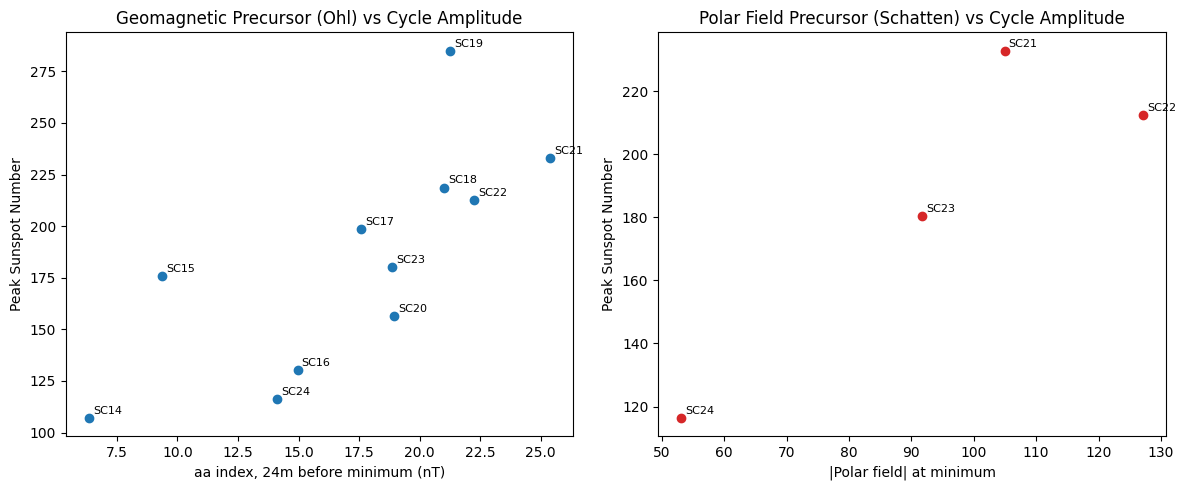

Saved plots/p8_precursor_correlations.png


In [7]:
merged = cyc.merge(precursors.drop(columns=['Start_Date']), on='Cycle_ID')

precursor_cols = ['aa_at_min', 'aa_pre12', 'aa_pre24', 'polar_field_at_min', 'polar_field_abs_at_min']
corr_table = merged[precursor_cols + ['Peak_Sunspot_Number', 'Rise_Time_months']].corr()

print("Correlation of precursors with cycle Peak_Sunspot_Number and Rise_Time_months:\n")
print(corr_table.loc[precursor_cols, ['Peak_Sunspot_Number', 'Rise_Time_months']].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

m1 = merged.dropna(subset=['aa_pre24', 'Peak_Sunspot_Number'])
axes[0].scatter(m1['aa_pre24'], m1['Peak_Sunspot_Number'], color='tab:blue')
for _, r in m1.iterrows():
    axes[0].annotate(f"SC{int(r['Cycle_ID'])}", (r['aa_pre24'], r['Peak_Sunspot_Number']),
                      fontsize=8, xytext=(3, 3), textcoords='offset points')
axes[0].set_xlabel('aa index, 24m before minimum (nT)')
axes[0].set_ylabel('Peak Sunspot Number')
axes[0].set_title('Geomagnetic Precursor (Ohl) vs Cycle Amplitude')

m2 = merged.dropna(subset=['polar_field_abs_at_min', 'Peak_Sunspot_Number'])
axes[1].scatter(m2['polar_field_abs_at_min'], m2['Peak_Sunspot_Number'], color='tab:red')
for _, r in m2.iterrows():
    axes[1].annotate(f"SC{int(r['Cycle_ID'])}", (r['polar_field_abs_at_min'], r['Peak_Sunspot_Number']),
                      fontsize=8, xytext=(3, 3), textcoords='offset points')
axes[1].set_xlabel('|Polar field| at minimum')
axes[1].set_ylabel('Peak Sunspot Number')
axes[1].set_title('Polar Field Precursor (Schatten) vs Cycle Amplitude')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p8_precursor_correlations.png', dpi=120)
plt.show()
print("Saved plots/p8_precursor_correlations.png")


## 8. Save Augmented Cycle Database

In [8]:
out_path = DATA_DIR / 'Cycle_Database_with_precursors.csv'
merged.to_csv(out_path, index=False)

print(f"Saved augmented cycle database to {out_path}")
print(f"Shape: {merged.shape}")
print(f"\nNew precursor columns: {precursor_cols}")

merged[['Cycle_ID', 'Start_Date', 'Peak_Sunspot_Number', 'Rise_Time_months'] + precursor_cols].tail(10)


Saved augmented cycle database to ..\data\Cycle_Database_with_precursors.csv
Shape: (24, 63)

New precursor columns: ['aa_at_min', 'aa_pre12', 'aa_pre24', 'polar_field_at_min', 'polar_field_abs_at_min']


,Cycle_ID,Start_Date,Peak_Sunspot_Number,Rise_Time_months,aa_at_min,aa_pre12,aa_pre24,polar_field_at_min,polar_field_abs_at_min
14,15,1913-07-01,175.7,49.0,8.344895,9.092538,9.352998,NaN,NaN
15,16,1923-08-01,130.2,56.0,10.404246,12.014209,14.961164,NaN,NaN
16,17,1933-09-01,198.6,43.0,14.998724,15.571334,17.593522,NaN,NaN
17,18,1944-02-01,218.7,38.9,21.096395,22.380266,21.003413,NaN,NaN
18,19,1954-04-01,285.0,47.0,16.049876,19.165757,21.238479,NaN,NaN
19,20,1964-10-01,156.6,49.0,14.084426,16.744015,18.942150,NaN,NaN
20,21,1976-03-01,232.9,45.0,21.140706,21.885454,25.394092,104.933333,104.933333
21,22,1986-09-01,212.5,38.0,18.183989,21.741150,22.230599,-127.102564,127.102564
22,23,1996-08-01,180.3,63.0,17.642816,17.244069,18.870990,91.685897,91.685897
23,24,2008-12-01,116.4,64.0,10.121269,13.054536,14.108589,-53.108974,53.108974


## 9. Summary & Next Steps (Phase 8b)

**What we built:**
- Parsed 125 years of geomagnetic aa index data (1900-2024, 3-hourly -> monthly means)
- Parsed 49 years of Wilcox polar field data (1976-2025, ~10-day cadence -> monthly means)
- Extracted 5 precursor features (`aa_at_min`, `aa_pre12`, `aa_pre24`, `polar_field_at_min`,
  `polar_field_abs_at_min`) for each of the 24 cycles, where data coverage allows
- Saved `data/Cycle_Database_with_precursors.csv` for downstream modeling

**Coverage caveats:**
- aa index precursors (with full 24-month lookback) are available from roughly **SC11 onward**
  (aa series starts 1868)
- Polar field precursors are only available for **SC21-SC24** (Wilcox data starts 1976) — too few
  cycles (N=4) for standalone LOCO CV, but useful as an auxiliary feature for recent cycles

**Phase 8b plan:**
1. Add `aa_pre24` / `polar_field_abs_at_min` as extra features to the Phase 6 amplitude model and
   re-run LOCO CV to see if the classic Ohl/Schatten precursors improve peak-amplitude predictions
2. For Phase 7v2 (running timing forecast), test whether precursor features help the **early
   pre-peak window (T<24m)**, which is currently the weakest part of the model (MAE ~8m)
3. Explore TDA features (persistent homology / Betti numbers) on SSN and magnetogram-derived time
   series as a longer-term Phase 9 direction
